Markov chain Monte Carlo simulations of the 1D Ising model.

[-1.   -0.95 -0.9  ... -0.15 -0.15 -0.15]


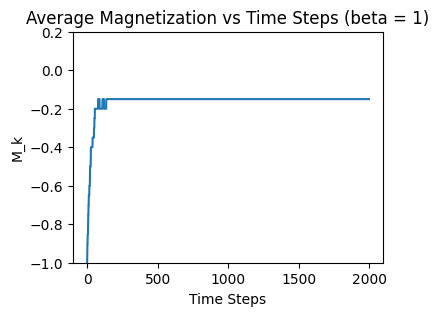

In [11]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
m = 40
numsteps = 2000
beta = 5

x = np.full((numsteps, m), -1)

def alpha(X, k, beta):
    if k == 0:
        Hdiff = -2 * (X[k] * X[k+1] + X[k])
    elif k == m-1:
        Hdiff = -2 * (X[k-1] * X[k] + X[k])
    else:
        Hdiff = -2 * (X[k-1] * X[k] + X[k] * X[k+1] + X[k])

    if 1 < np.exp(-beta * Hdiff):
        return 1
    else:
        return np.exp(-beta * Hdiff)
    
for i in range(numsteps-1):   
    k = rng.integers(0, m)
    U = rng.uniform(0, 1)
    if U < alpha(x[i],k,beta):
        for index, element in enumerate(x[i]):
            if index != k:
                x[i+1][index] = element
            else:
                x[i+1][index] = -1 * element
    else:
        for index, element in enumerate(x[i]):
            x[i+1][index] = element

def compute_mk(x, m):
    M = np.zeros(numsteps)
    for j in range(numsteps):
        M[j] = sum(x[j]) / m
    return M

print(compute_mk(x, m))
fig, ax = plt.subplots(figsize=(4,3))
ax.plot(np.arange(numsteps), compute_mk(x, m))
ax.set_title("Average Magnetization vs Time Steps (beta = 1)")
ax.set_xlabel("Time Steps")
ax.set_ylabel("M_k")
ax.set_ylim([-1, 0.2])
plt.show()

In [ ]:
def hamiltonian(vector):
    sum1 = 0
    for i in range(len(vector)-1):
        sum1 += vector[i] * vector[i+1]
    sum2 = 0
    for i in range(len(vector)):
        sum2 += vector[i]
    return - sum1 - sum2